## Tugas Besar Data Mining ##

### Kelompok 8_SI-48-02 ###

1. Dea Rizky Ananda
2. DeasyHana Luisyana Manurung
3. Muhammad Noval Agustian
4. I Nyoman Aditya Wahyu

# Analisis Data Mining pada Dataset Cardiovascular Disease Risk Assessment

## Tujuan
Melakukan pengelompokan data pasien menggunakan algoritma K-Means dan melakukan klasifikasi hasil cluster menggunakan Logistic Regression dan Naive Bayes.


## Informasi Dataset ##

**Link Dataset :** https://www.kaggle.com/datasets/ahmeduzaki/cardiovascular-disease-risk-assessment-dataset

**Import Library**

In [258]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Understanding

Dataset yang digunakan adalah Cardiovascular Disease Risk Assessment Dataset.

Dataset ini berisi informasi kesehatan individu seperti usia, BMI, tekanan darah, kadar kolesterol, kadar gula darah, aktivitas fisik, dan faktor kesehatan lainnya.

Tujuan analisis adalah mengidentifikasi pola pengelompokan data berdasarkan karakteristik kesehatan yang dimiliki setiap individu.

**Load Dataset**


In [259]:
df = pd.read_csv("CVD Dataset.csv")

# Data Identification

Tahap ini dilakukan untuk memahami struktur dataset yang digunakan sebelum proses pengolahan data dilakukan.


**Melihat 5 Data Pertama**

In [260]:
df.head()

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Low,N,171.0,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,High,Y,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,High,Y,183.0,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,High,Y,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,High,N,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY


**Mengetahui Jumlah Baris dan Kolom**

In [261]:
print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Baris : 1529
Jumlah Kolom : 22


**Menampilkan Nama Kolom**

In [262]:
for col in df.columns:
    print(col)

Sex
Age
Weight (kg)
Height (m)
BMI
Abdominal Circumference (cm)
Blood Pressure (mmHg)
Total Cholesterol (mg/dL)
HDL (mg/dL)
Fasting Blood Sugar (mg/dL)
Smoking Status
Diabetes Status
Physical Activity Level
Family History of CVD
Height (cm)
Waist-to-Height Ratio
Systolic BP
Diastolic BP
Blood Pressure Category
Estimated LDL (mg/dL)
CVD Risk Score
CVD Risk Level


**Melihat Info Data**

In [263]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   object 
 1   Age                           1451 non-null   float64
 2   Weight (kg)                   1448 non-null   float64
 3   Height (m)                    1462 non-null   float64
 4   BMI                           1465 non-null   float64
 5   Abdominal Circumference (cm)  1462 non-null   float64
 6   Blood Pressure (mmHg)         1529 non-null   object 
 7   Total Cholesterol (mg/dL)     1456 non-null   float64
 8   HDL (mg/dL)                   1449 non-null   float64
 9   Fasting Blood Sugar (mg/dL)   1462 non-null   float64
 10  Smoking Status                1529 non-null   object 
 11  Diabetes Status               1529 non-null   object 
 12  Physical Activity Level       1529 non-null   object 
 13  Fam


Dataset terdiri dari 1529 record dengan kombinasi variabel numerik dan kategorikal.

Variabel numerik akan digunakan pada proses clustering karena algoritma K-Means bekerja berdasarkan perhitungan jarak antar data.


**Mengecek Missing Value**

In [264]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing.sort_values(ascending=False))

Diastolic BP                    82
Weight (kg)                     81
HDL (mg/dL)                     80
Waist-to-Height Ratio           79
Age                             78
Height (cm)                     74
Total Cholesterol (mg/dL)       73
Systolic BP                     71
CVD Risk Score                  70
Estimated LDL (mg/dL)           69
Height (m)                      67
Abdominal Circumference (cm)    67
Fasting Blood Sugar (mg/dL)     67
BMI                             64
dtype: int64


**Persentase Missing Value**

In [265]:
missing_percent = (
    df.isnull().sum() /
    len(df)
) * 100

missing_percent = missing_percent[
    missing_percent > 0
]

print(
    missing_percent.sort_values(
        ascending=False
    )
)

Diastolic BP                    5.362982
Weight (kg)                     5.297580
HDL (mg/dL)                     5.232178
Waist-to-Height Ratio           5.166776
Age                             5.101373
Height (cm)                     4.839765
Total Cholesterol (mg/dL)       4.774362
Systolic BP                     4.643558
CVD Risk Score                  4.578156
Estimated LDL (mg/dL)           4.512753
Height (m)                      4.381949
Abdominal Circumference (cm)    4.381949
Fasting Blood Sugar (mg/dL)     4.381949
BMI                             4.185742
dtype: float64


**Melihat statistik data**

In [266]:
df.describe()

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1451.000000,1448.000000,1462.000000,1465.000000,1462.000000,1456.000000,1449.000000,1462.000000,1455.000000,1450.000000,1458.000000,1447.000000,1460.000000,1459.000000
mean,47.025500,85.917427,1.754111,28.465997,91.773214,198.539148,56.197378,117.485636,175.390600,0.525727,125.627572,82.917761,111.550685,16.960925
std,12.421063,21.012580,0.113090,7.038685,12.823573,57.794099,16.066754,30.289174,11.251527,0.081213,22.112099,14.731277,58.866220,2.436192
min,25.000000,50.100000,1.502000,15.000000,70.000000,100.000000,30.000000,70.000000,150.000000,0.360000,90.000000,60.000000,-18.000000,10.530000
25%,37.000000,67.050000,1.660000,22.629000,80.500000,150.000000,42.000000,92.000000,166.000000,0.460000,107.000000,71.000000,61.000000,15.205000
50%,46.000000,86.614500,1.755000,28.159000,91.600000,197.000000,56.000000,115.000000,175.694000,0.522000,125.000000,82.000000,109.000000,16.880000
75%,55.000000,105.000000,1.845500,34.000000,102.269000,249.000000,70.000000,138.000000,184.208500,0.583750,141.000000,93.000000,159.000000,18.630000
max,79.000000,120.000000,2.000000,46.200000,119.996000,300.000000,89.000000,198.000000,199.960000,0.787000,179.000000,119.000000,237.000000,24.170000


**Mengelompokkan Kolom Numeric dan Categorical**

In [267]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

categorical_cols = df.select_dtypes(
    exclude=np.number
).columns

**Menampilkan hasilnya**

In [268]:
print("Kolom Numerik")
print(numeric_cols)

print("\nKolom Kategorikal")
print(categorical_cols)

Kolom Numerik
Index(['Age', 'Weight (kg)', 'Height (m)', 'BMI',
       'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)',
       'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Height (cm)',
       'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
       'Estimated LDL (mg/dL)', 'CVD Risk Score'],
      dtype='object')

Kolom Kategorikal
Index(['Sex', 'Blood Pressure (mmHg)', 'Smoking Status', 'Diabetes Status',
       'Physical Activity Level', 'Family History of CVD',
       'Blood Pressure Category', 'CVD Risk Level'],
      dtype='object')


# Penghapusan Variabel

Pada tahap ini dilakukan penghapusan beberapa kolom yang tidak digunakan dalam proses analisis.

Kolom yang dihapus yaitu:

1. CVD Risk Score
   - Merupakan label risiko yang sudah tersedia pada dataset.
   - Dihapus karena proses clustering menggunakan metode K-Means yang bersifat unsupervised learning sehingga tidak menggunakan label target.

2. CVD Risk Level
   - Merupakan kategori tingkat risiko kardiovaskular yang juga berfungsi sebagai label target.
   - Dihapus agar proses clustering dilakukan murni berdasarkan karakteristik data.

3. Height (m)
   - Dihapus karena informasi tinggi badan sudah direpresentasikan oleh kolom Height (cm).
   - Kedua kolom memiliki informasi yang sama sehingga salah satunya perlu dihapus untuk menghindari redundansi data.

In [269]:
df = df.drop(
    columns=[
        'CVD Risk Score',
        'CVD Risk Level',
        'Height (m)'
    ]
)

# Penanganan Missing Value ##

Missing value pada variabel numerik diisi menggunakan median karena median lebih stabil terhadap outlier dibandingkan mean.

In [270]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

df[numeric_cols] = df[
    numeric_cols
].fillna(
    df[numeric_cols].median()
)

### Interpretasi Histogram ###

Histogram digunakan untuk melihat distribusi masing-masing variabel numerik.

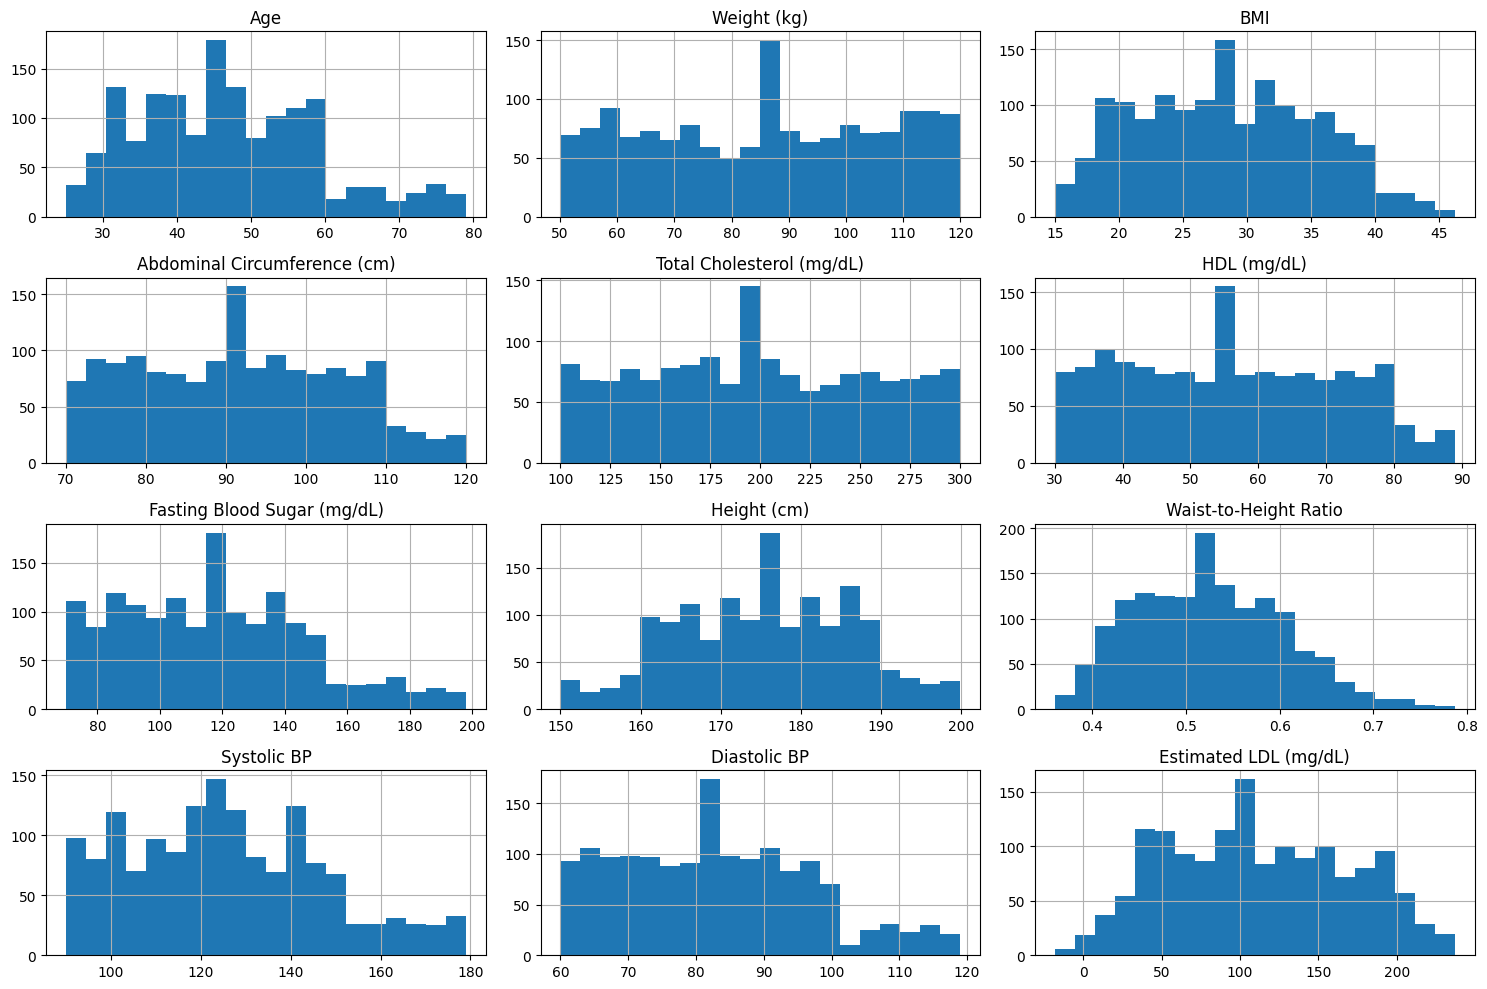

In [271]:
import matplotlib.pyplot as plt

df.hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

Sebagian besar variabel memiliki distribusi yang cukup merata dan tidak menunjukkan pola yang ekstrem.

### Interpretasi Boxplot ###

Boxplot digunakan untuk mendeteksi kemungkinan adanya outlier.

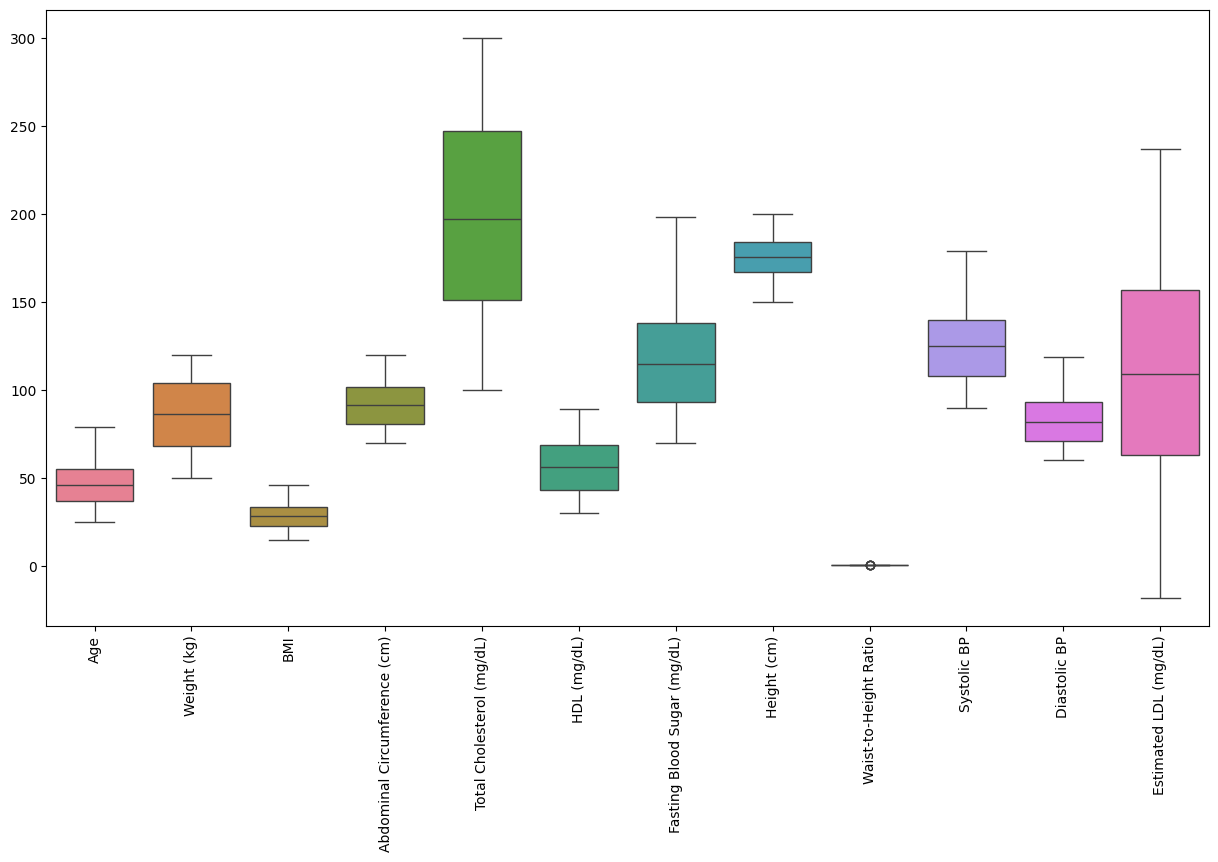

In [272]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df.select_dtypes(include='number'))

plt.xticks(rotation=90)
plt.show()

Berdasarkan visualisasi, tidak ditemukan outlier yang sangat mendominasi sehingga data tetap digunakan tanpa proses penghapusan outlier.

### Interpretasi Heatmap ###

Heatmap digunakan untuk melihat hubungan antar variabel numerik.

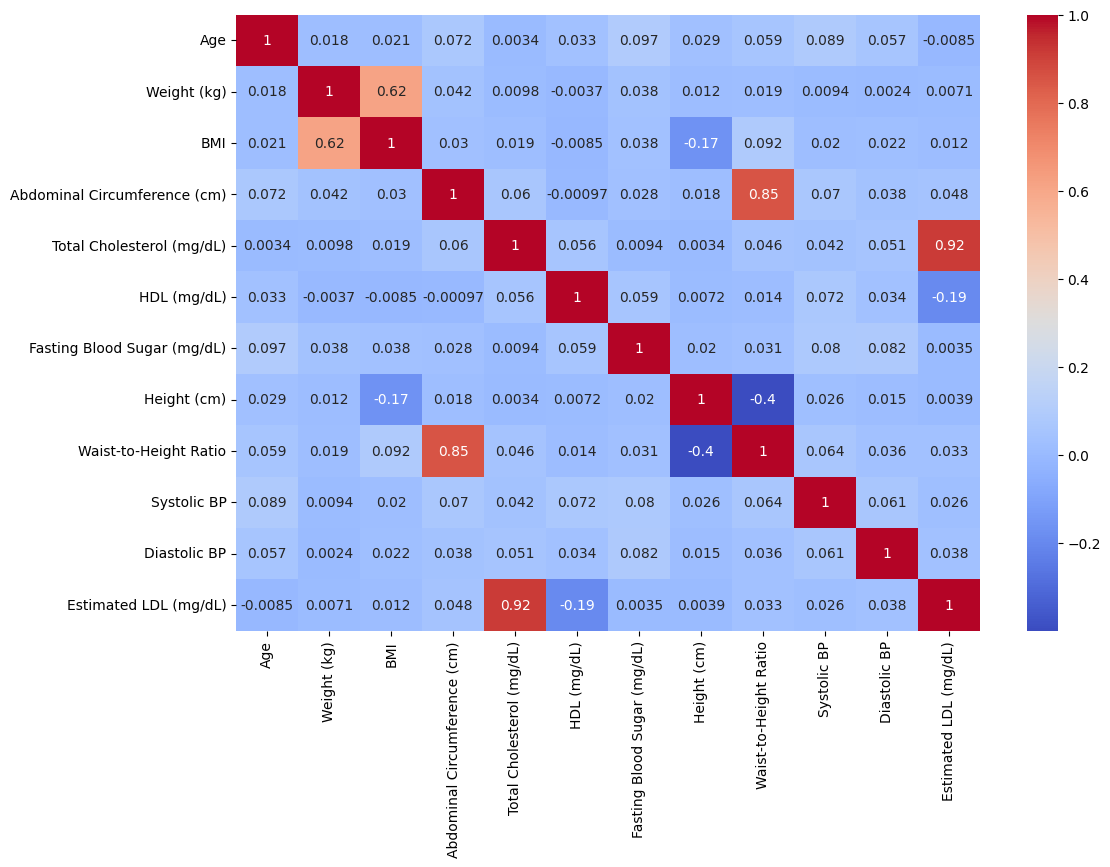

In [273]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

Ditemukan korelasi yang sangat tinggi antara Total Cholesterol dan Estimated LDL serta antara Abdominal Circumference dan Waist-to-Height Ratio.

Oleh karena itu dipilih variabel yang paling representatif untuk proses clustering.

## Verifikasi Missing Value

Setelah proses imputasi dilakukan, dilakukan pengecekan ulang untuk memastikan tidak ada missing value yang tersisa pada dataset.

Dataset yang bersih diperlukan agar proses clustering dan klasifikasi dapat berjalan dengan baik.
Setelah dataset bersih dari missing value, dilakukan pemilihan variabel yang akan digunakan pada proses clustering.

In [274]:
df.isnull().sum().sum()

np.int64(0)

# Pemilihan Variabel untuk Clustering
Variabel yang digunakan dalam proses clustering adalah:

1. Age
2. BMI
3. Total Cholesterol (mg/dL)
4. Systolic BP

Keempat variabel tersebut dipilih berdasarkan relevansi medis terhadap risiko penyakit kardiovaskular serta untuk menghindari redundansi akibat korelasi yang sangat tinggi antar variabel.

**Memilih 4 variable**

In [275]:
features = [
    'Age',
    'BMI',
    'Total Cholesterol (mg/dL)',
    'Systolic BP'
]

X = df[features]

# Standardisasi Data

K-Means menggunakan perhitungan jarak sehingga seluruh variabel perlu berada pada skala yang seragam.

Oleh karena itu dilakukan standardisasi menggunakan StandardScaler.

**StandardScaler**

In [276]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Penentuan Jumlah Cluster Optimal
Sebelum melakukan clustering dengan K-Means, jumlah cluster optimal (k) ditentukan terlebih dahulu menggunakan **Elbow Method** dan **Silhouette Score**.

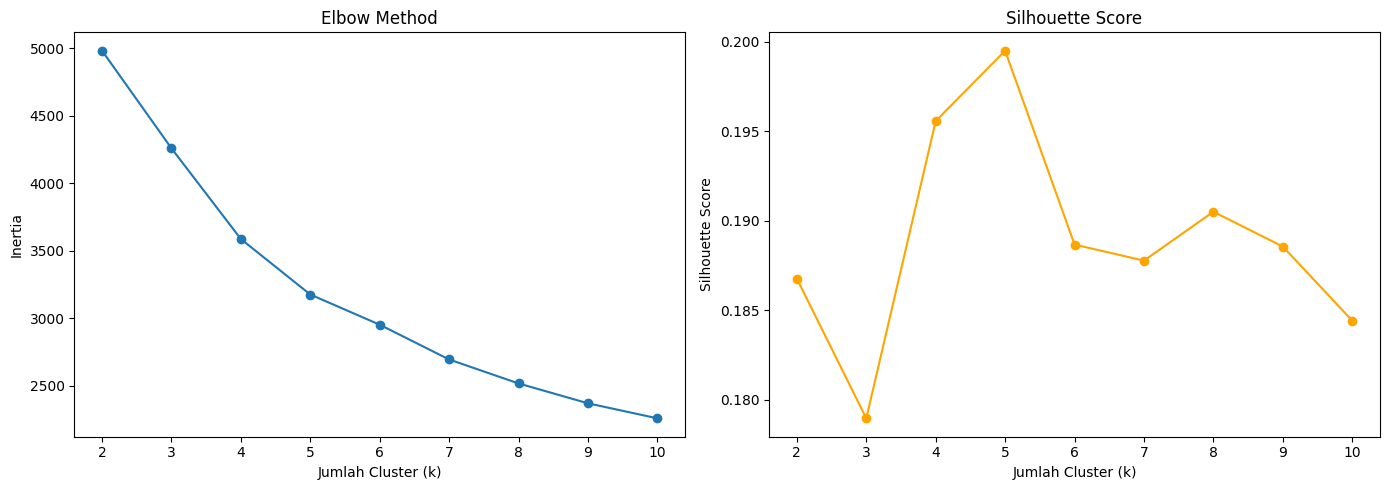

In [277]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(14,5))

ax[0].plot(K_range, inertia, marker='o')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('Jumlah Cluster (k)')
ax[0].set_ylabel('Inertia')

ax[1].plot(K_range, silhouette, marker='o', color='orange')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Jumlah Cluster (k)')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# Clustering Menggunakan K-Means

Proses clustering dilakukan menggunakan algoritma K-Means dengan jumlah cluster sebanyak 2 

Meskipun hasil evaluasi menunjukkan jumlah cluster optimal sebesar 5, penelitian ini menggunakan 2 cluster untuk menyederhanakan segmentasi data menjadi dua kelompok utama sehingga lebih mudah diinterpretasikan.


**K-Means (K=2)**

In [278]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

**Cek Hasil Cluster**

In [279]:
df['Cluster'].value_counts()

Cluster
0    808
1    721
Name: count, dtype: int64

**Analisis Karakteristik Cluster**

In [280]:
df.groupby('Cluster')[features].mean()

,Age,BMI,Total Cholesterol (mg/dL),Systolic BP
Cluster,,,,
0,46.108911,27.507400,154.980198,121.075495
1,47.941748,29.513014,247.198336,130.667129


**Centroid Tiap Cluster (Skala Asli)**

In [281]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=features)
centroids_df.index.name = 'Cluster'

print("Centroid tiap cluster (dalam skala data asli):")
centroids_df

Centroid tiap cluster (dalam skala data asli):


,Age,BMI,Total Cholesterol (mg/dL),Systolic BP
Cluster,,,,
0,46.110422,27.461991,154.870968,121.151365
1,47.934993,29.558087,247.065007,130.556017


## Karakteristik Cluster

Berdasarkan rata-rata setiap variabel:

Cluster 0 memiliki:
- BMI lebih rendah
- Total Cholesterol lebih rendah
- Systolic BP lebih rendah

Cluster 1 memiliki:
- BMI lebih tinggi
- Total Cholesterol lebih tinggi
- Systolic BP lebih tinggi

Perbedaan terbesar terlihat pada variabel Total Cholesterol sehingga variabel tersebut menjadi pembeda utama antar cluster.

Hasil ini menunjukkan bahwa kedua cluster memiliki karakteristik kesehatan yang berbeda.

**Visualisasi Cluster**

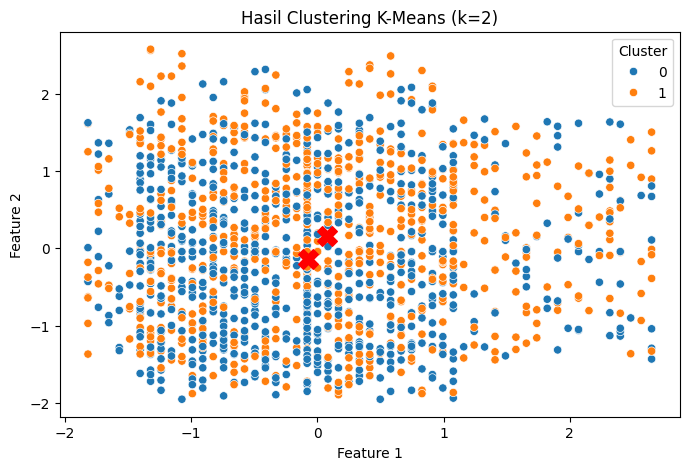

In [282]:
centroids = kmeans.cluster_centers_
plt.figure(figsize=(8,5))

sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=df['Cluster'])

plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X', s=200)

plt.title('Hasil Clustering K-Means (k=2)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

Visualisasi menunjukkan bahwa data berhasil dikelompokkan menjadi dua kelompok berdasarkan kemiripan karakteristik kesehatan.

Pemisahan cluster terlihat terutama pada variabel Total Cholesterol.

# Klasifikasi Cluster

Hasil clustering digunakan sebagai target baru untuk proses klasifikasi.

Tujuan tahap ini adalah memprediksi apakah suatu data termasuk ke Cluster 0 atau Cluster 1.

**Menampilkan kolom cluster**

In [283]:
df['Cluster']

0       1
1       0
2       0
3       0
4       0
       ..
1524    0
1525    1
1526    1
1527    0
1528    1
Name: Cluster, Length: 1529, dtype: int32

**Penentuan Variabel Input (X) dan Target (Y)**

Pada tahap klasifikasi ini, hasil clustering yang telah diperoleh sebelumnya digunakan sebagai label target (Y). Variabel X merupakan fitur-fitur yang sama dengan yang digunakan pada proses clustering, yaitu Age, BMI, Total Cholesterol, dan Systolic BP. Model klasifikasi akan dilatih untuk memprediksi nilai Y (Cluster) berdasarkan nilai X.

In [284]:
X = df[features]
Y = df['Cluster']

# Pembagian Data

Data dibagi menjadi data latih dan data uji dengan rasio 80:20.

Standardisasi dilakukan setelah pembagian data untuk menghindari data leakage.

Train Test Split

In [285]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

StandardScaler

In [286]:
scaler_lr = StandardScaler()

X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled = scaler_lr.transform(X_test)

Logistic Regression (LR)

In [287]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

Evaluasi LR

In [288]:
from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print("Accuracy LR :", acc_lr)

Accuracy LR : 0.9901960784313726


### Hasil Logistic Regression ###

Model Logistic Regression menghasilkan akurasi sebesar 99,02%.


Naive Bayes (NB)

In [289]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)

Evaluasi NB

In [290]:
acc_nb = accuracy_score(
    y_test,
    y_pred_nb
)

print("Accuracy NB :", acc_nb)

Accuracy NB : 0.934640522875817


### Hasil Naive Bayes ###

Model Naive Bayes menghasilkan akurasi sebesar 93,46%.

Performa model masih baik namun lebih rendah dibandingkan Logistic Regression.

# Perbandingan Model

Perbandingan dilakukan menggunakan metrik Accuracy, Precision, Recall, dan F1-Score.

In [291]:
print("Logistic Regression :", acc_lr)
print("Naive Bayes :", acc_nb)

Logistic Regression : 0.9901960784313726
Naive Bayes : 0.934640522875817


In [292]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       173
           1       1.00      0.98      0.99       133

    accuracy                           0.99       306
   macro avg       0.99      0.99      0.99       306
weighted avg       0.99      0.99      0.99       306

              precision    recall  f1-score   support

           0       0.95      0.94      0.94       173
           1       0.92      0.93      0.93       133

    accuracy                           0.93       306
   macro avg       0.93      0.93      0.93       306
weighted avg       0.93      0.93      0.93       306



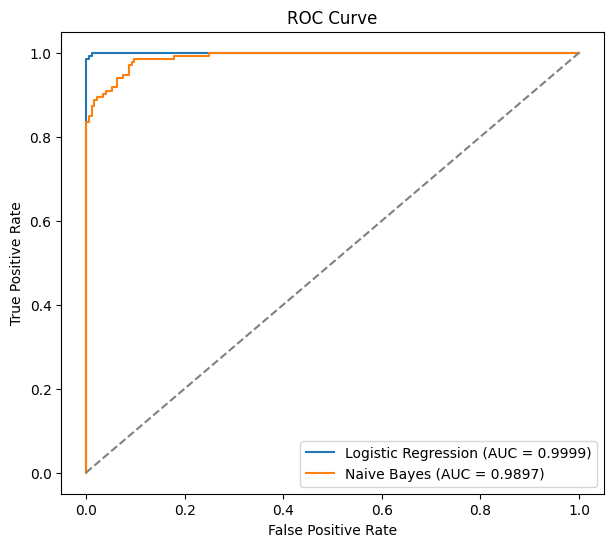

In [293]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_nb = nb.predict_proba(X_test_scaled)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_nb = roc_auc_score(y_test, y_prob_nb)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

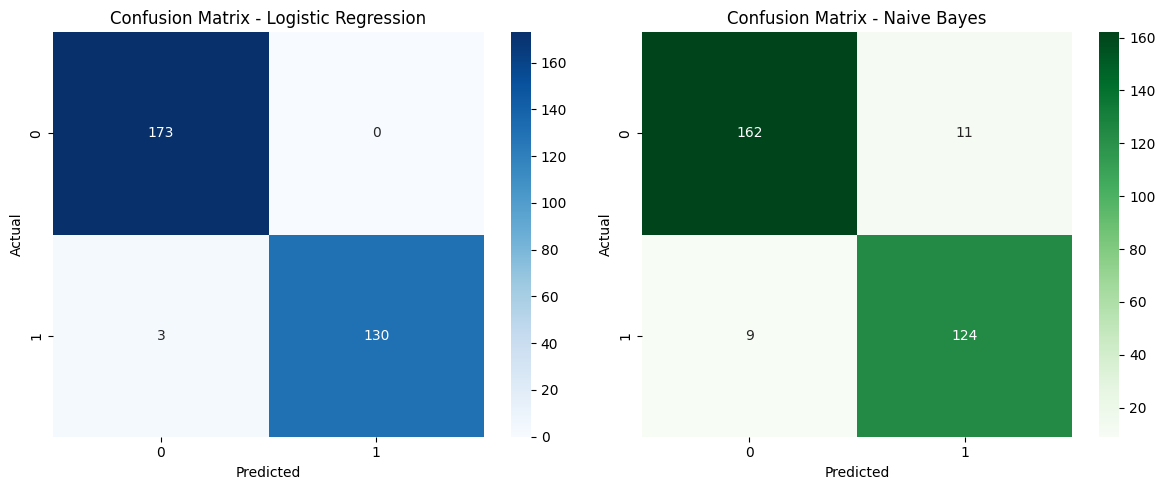

In [294]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_nb = confusion_matrix(y_test, y_pred_nb)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix - Logistic Regression')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Confusion Matrix - Naive Bayes')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Analisis Feature Importance dilakukan untuk mengetahui variabel yang paling berpengaruh dalam proses klasifikasi hasil clustering.

Nilai koefisien Logistic Regression digunakan sebagai indikator tingkat pengaruh masing-masing fitur terhadap pembentukan cluster.

In [295]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_[0]
})

importance['Abs_Coefficient'] = abs(
    importance['Coefficient']
)

importance = importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

print(importance)

                     Feature  Coefficient  Abs_Coefficient
2  Total Cholesterol (mg/dL)     8.152190         8.152190
3                Systolic BP     2.166706         2.166706
1                        BMI     1.452246         1.452246
0                        Age     0.600153         0.600153



Berdasarkan koefisien Logistic Regression, Total Cholesterol merupakan variabel yang paling berpengaruh dalam membedakan Cluster 0 dan Cluster 1.

Urutan pengaruh variabel:

1. Total Cholesterol
2. Systolic BP
3. BMI
4. Age

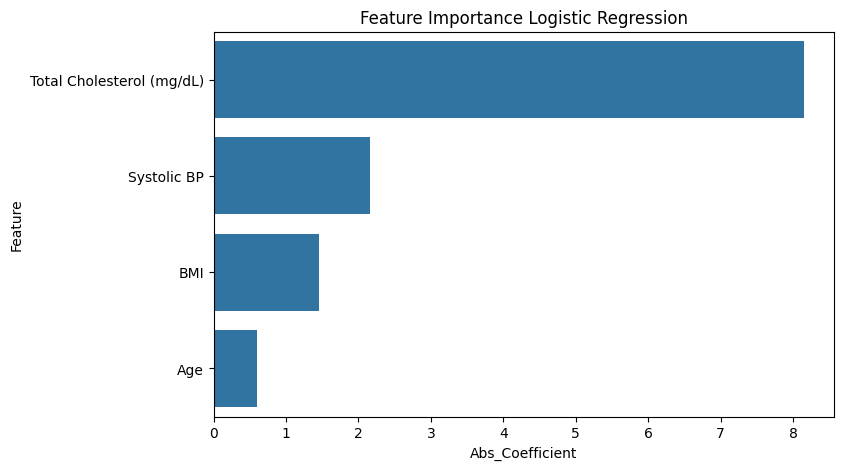

In [296]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Abs_Coefficient',
    y='Feature'
)

plt.title('Feature Importance Logistic Regression')
plt.show()

In [297]:
import joblib

bundle = {
    "kmeans": kmeans,
    "scaler_kmeans": scaler,   # <- ini yang benar
    "logreg": lr,
    "scaler_lr": scaler_lr
}

joblib.dump(bundle, "model_bundle.pkl")

['model_bundle.pkl']

In [303]:

%%writefile app.py

import streamlit as st
import joblib
import pandas as pd

# Load model dan scaler
bundle = joblib.load("model_bundle.pkl")

model = bundle["logreg"]
scaler = bundle["scaler_lr"]

# Konfigurasi halaman
st.set_page_config(
    page_title="Cardiovascular Risk Assessment",
    layout="centered"
)

# Header
st.title("Cardiovascular Risk Assessment")

st.caption(
    "Estimasi kelompok risiko kardiovaskular berdasarkan usia, BMI, "
    "kolesterol, dan tekanan darah sistolik."
)

st.divider()

# Input Data
st.subheader("Data Pasien")

with st.form("prediction_form"):

    col1, col2 = st.columns(2)

    with col1:
        age = st.number_input(
            "Usia (tahun)",
            min_value=1,
            max_value=120,
            value=30
        )

        chol = st.number_input(
            "Total Cholesterol (mg/dL)",
            min_value=50.0,
            max_value=500.0,
            value=180.0
        )

    with col2:
        bmi = st.number_input(
            "BMI",
            min_value=10.0,
            max_value=60.0,
            value=25.0
        )

        bp = st.number_input(
            "Systolic BP (mmHg)",
            min_value=50.0,
            max_value=250.0,
            value=120.0
        )

    submit = st.form_submit_button(
        "Jalankan Asesmen",
        use_container_width=True
    )

# Hasil Prediksi
if submit:

    input_data = pd.DataFrame(
        [[age, bmi, chol, bp]],
        columns=[
            "Age",
            "BMI",
            "Total Cholesterol (mg/dL)",
            "Systolic BP"
        ]
    )

    scaled_data = scaler.transform(input_data)

    prediction = model.predict(scaled_data)[0]

    st.divider()
    st.subheader("Hasil Prediksi")

    col1, col2 = st.columns(2)

    with col1:
        st.metric(
            "Cluster",
            prediction
        )

    with col2:
        st.metric(
            "Kategori Risiko",
            "Rendah" if prediction == 0 else "Tinggi"
        )

    summary = pd.DataFrame({
        "Parameter": [
            "Usia",
            "BMI",
            "Kolesterol",
            "Systolic BP"
        ],
        "Nilai": [
            f"{age} tahun",
            f"{bmi:.1f}",
            f"{chol:.0f} mg/dL",
            f"{bp:.0f} mmHg"
        ]
    })

    with st.container(border=True):
        st.subheader("Ringkasan Data")
        st.table(summary)

    if prediction == 0:
        st.success(
            "Pasien termasuk ke dalam kelompok Risiko Rendah."
        )
    else:
        st.error(
            "Pasien termasuk ke dalam kelompok Risiko Tinggi."
        )

    st.info(
        "Hasil ini merupakan keluaran model Logistic Regression "
        "dan digunakan sebagai alat bantu analisis, bukan diagnosis medis."
    )

else:
    st.info(
        "Masukkan data pasien lalu klik 'Jalankan Asesmen' untuk melihat hasil prediksi."
    )


Overwriting app.py


In [301]:
def run_streamlit():
    os.system("streamlit run app.py --server.port 8501")

thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()

time.sleep(5)

public_url = ngrok.connect(addr=8501)
print(f"Streamlit app is live at: {public_url}")

Streamlit app is live at: NgrokTunnel: "https://vitalize-object-defensive.ngrok-free.dev" -> "http://localhost:8501"


# Kesimpulan

1. Dataset berhasil dikelompokkan menjadi dua cluster menggunakan K-Means.
2. Pemilihan fitur dilakukan berdasarkan relevansi kesehatan dan hasil analisis korelasi.
3. Hasil clustering menunjukkan adanya perbedaan karakteristik antar kelompok data.
4. Logistic Regression memberikan performa terbaik dengan akurasi 99,02%.
5. Naive Bayes menghasilkan akurasi 93,46%.
6. Total Cholesterol merupakan variabel yang paling berpengaruh dalam pembentukan cluster.